# User Retention Cohort Analysis
Dataset: UCI Online Retail | Tools: Pandas, Matplotlib, Seaborn

# Business Question
After a customer makes their first purchase, do they come back or not?
This analysis tracks 4,338 customers across 13 monthly cohorts to measure retention.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df=pd.read_excel(r'D:\Programming\Python\Data Analysis\Online_retail\Online Retail\Online Retail.xlsx')

In [5]:
print(df.shape)
#tells how many rows and columns are there in (rows,columns) format
#rows=541909
#columns=8


(541909, 8)


In [6]:
print(df.dtypes)
# prints the datatype of each row

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


In [7]:
df.head()
#prints the first few rows

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [8]:
df.isnull().sum()
#tells us howmany values are null/empty
#we see that ther are 1454 rows where description is empty and 
#also there are 135080 rows where customerID is not present

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
#Do customers come back after their first purchase, or do they buy once and disappear?

#in order to do that we need to track customers and we cannot track customers if we do not know their customerID
#so we remove those rows where customerID is not present
df=df.dropna(subset=['CustomerID'])
# now to checkthat it worked we can call the df.shape and see how mant (rows ,columns) are there
# originally 541909 rows were there and out of those many rows 135080 rows did not have customerID 
#so this code removed those 135080 rows out of our data frame
#implies 541909-135080=406829 rows are still present
#and if we run df.shape we will be getting (406829,8) as our answer

In [10]:
df.shape
#this code verifies that we deleted those rows that were missing customerID

(406829, 8)

In [11]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

In [12]:
#observations
# CustomerId is float datatype thats should be converted to integer datatype because i cannot imagine a customerId where
# customerID is a decimal number i mean how would you call the customer like 12.34 thats is wrong

# there is a possiblity that quantity will be 0 or negative values we do not want those rows too

# regarding the unitprice column make sure that all those values are positive 

# regarding  invoiceno and stockcode  let them remain object datatype as they do not help 
# in any way determining if a customer is repurchasing or not

# regarding description column it tells us what the customer has bought from the online store and no way answers our question
# that is the customer repeating or not we care that customer comes to our shop and buys and thats it what is bought that is a total 
# different question
# so description column does not really help in answering our question and we will drop that column

In [13]:
df['CustomerID'] = df['CustomerID'].astype(int)

In [14]:
#print(df['Quantity']>0)
df['Quantity']>0

0         True
1         True
2         True
3         True
4         True
          ... 
541904    True
541905    True
541906    True
541907    True
541908    True
Name: Quantity, Length: 406829, dtype: bool

In [15]:
# we see that there are 8905 rows where quantity is not > 0 and these rows need to be removed
df=df[df['Quantity']>0]

In [16]:
df['Quantity']>0
# all entries in quantity column are greater then 0
# now similar idea with unitprice column also

0         True
1         True
2         True
3         True
4         True
          ... 
541904    True
541905    True
541906    True
541907    True
541908    True
Name: Quantity, Length: 397924, dtype: bool

In [17]:
df['UnitPrice']>0

0         True
1         True
2         True
3         True
4         True
          ... 
541904    True
541905    True
541906    True
541907    True
541908    True
Name: UnitPrice, Length: 397924, dtype: bool

In [18]:
#there are 40 rows where unit price is is not > 0 and those rows needs to be removed
df=df[df['UnitPrice']>0]

In [19]:
df['UnitPrice']>0
#now all entries in unitprice column are greater then 0

0         True
1         True
2         True
3         True
4         True
          ... 
541904    True
541905    True
541906    True
541907    True
541908    True
Name: UnitPrice, Length: 397884, dtype: bool

In [20]:
df.drop('Description',inplace=True,axis=1)

In [21]:
df

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680,France
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680,France
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680,France
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680,France


In [22]:
# Check how many cancelled orders exist
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print(f"Cancelled orders: {len(cancelled)}")
print(cancelled['InvoiceNo'].head(10))

Cancelled orders: 0
Series([], Name: InvoiceNo, dtype: object)


In [23]:
df['InvoiceNo'] = df['InvoiceNo'].astype(int)

In [24]:
df.dtypes

InvoiceNo               int64
StockCode              object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID              int64
Country                   str
dtype: object

In [25]:
#cleaned data
print(f'Cleaned dataset shape:',df.shape)
print(f'Unique Customers:',df['CustomerID'].nunique())
print(f'Date Range:',df['InvoiceDate'].min(),'to',df['InvoiceDate'].max())
print(f'Countries:',df['Country'].nunique())

Cleaned dataset shape: (397884, 7)
Unique Customers: 4338
Date Range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Countries: 37


In [26]:
# add revenue column
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [27]:
df

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
...,...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680,France,10.20
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680,France,12.60
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680,France,16.60
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680,France,16.60


In [28]:
#add invoice month column
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [29]:
#add cohort month column
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'].transform(min).dt.to_period('M')

In [30]:
df

,InvoiceNo,StockCode,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceMonth,CohortMonth
0,536365,85123A,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12,2010-12
1,536365,71053,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12
2,536365,84406B,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12,2010-12
3,536365,84029G,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12
4,536365,84029E,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12,2010-12
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,12,2011-12-09 12:50:00,0.85,12680,France,10.20,2011-12,2011-08
541905,581587,22899,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011-12,2011-08
541906,581587,23254,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12,2011-08
541907,581587,23255,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12,2011-08


In [31]:
cohort_data = df.groupby(['CohortMonth','InvoiceMonth'])['CustomerID'].nunique().reset_index()

cohort_data.columns = ['CohortMonth','InvoiceMonth','Customers']

In [32]:
#cohort_index=invoicemonth-cohortmonth
cohort_data['CohortIndex'] = (cohort_data['InvoiceMonth'] - cohort_data['CohortMonth']).apply(lambda x: x.n)

In [33]:
cohort_matrix=cohort_data.pivot_table(index='CohortMonth',columns='CohortIndex',values='Customers')

In [34]:
cohort_size = cohort_matrix[0]
retention_matrix = cohort_matrix.divide(cohort_size,axis=0).round(3)*100 

In [35]:
print("Cohort sizes (new customers per month):")
print(cohort_size)
print("\nRetention matrix (first 5 columns):")
print(retention_matrix.iloc[:, :5])

Cohort sizes (new customers per month):
CohortMonth
2010-12    885.0
2011-01    417.0
2011-02    380.0
2011-03    452.0
2011-04    300.0
2011-05    284.0
2011-06    242.0
2011-07    188.0
2011-08    169.0
2011-09    299.0
2011-10    358.0
2011-11    323.0
2011-12     41.0
Freq: M, Name: 0, dtype: float64

Retention matrix (first 5 columns):
CohortIndex      0     1     2     3     4
CohortMonth                               
2010-12      100.0  36.6  32.3  38.4  36.3
2011-01      100.0  22.1  26.6  23.0  32.1
2011-02      100.0  18.7  18.7  28.4  27.1
2011-03      100.0  15.0  25.2  19.9  22.3
2011-04      100.0  21.3  20.3  21.0  19.7
2011-05      100.0  19.0  17.3  17.3  20.8
2011-06      100.0  17.4  15.7  26.4  23.1
2011-07      100.0  18.1  20.7  22.3  27.1
2011-08      100.0  20.7  24.9  24.3  12.4
2011-09      100.0  23.4  30.1  11.4   NaN
2011-10      100.0  24.0  11.5   NaN   NaN
2011-11      100.0  11.1   NaN   NaN   NaN
2011-12      100.0   NaN   NaN   NaN   NaN


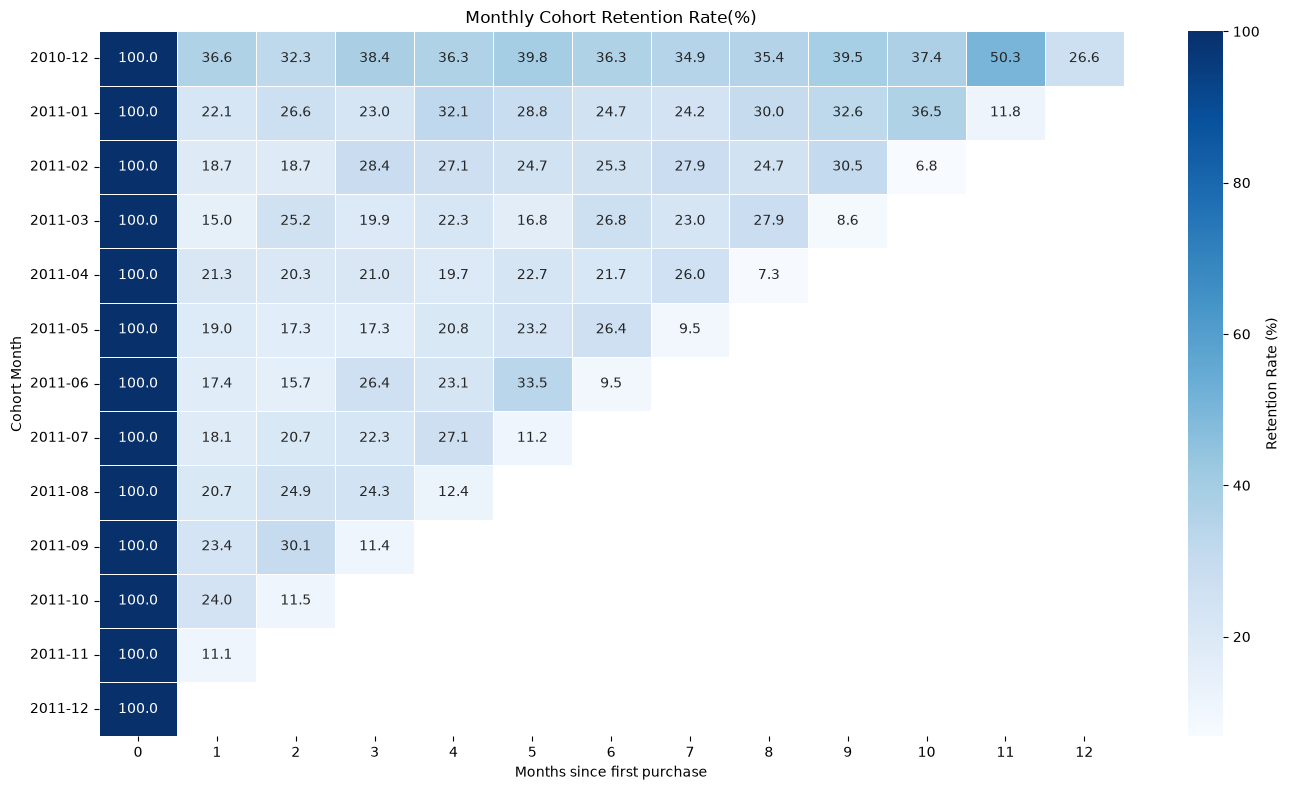

<Figure size 640x480 with 0 Axes>

In [36]:
plt.figure(figsize=(14,8))
sns.heatmap(
    retention_matrix,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    mask=retention_matrix.isnull(),
    linewidths=0.5,
    cbar_kws={'label': 'Retention Rate (%)'}
)
plt.title('Monthly Cohort Retention Rate(%)')
plt.xlabel('Months since first purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.show()
plt.savefig("Retention HeatMap")

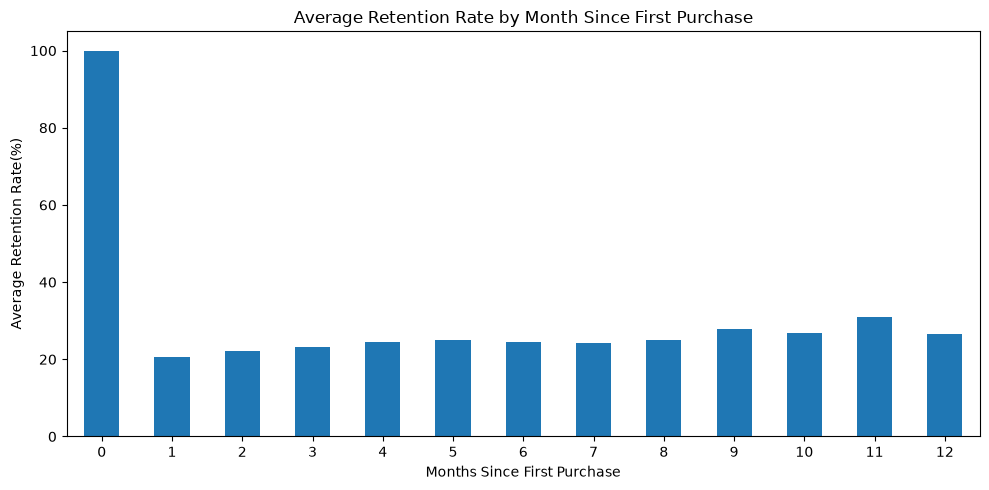

<Figure size 640x480 with 0 Axes>

In [37]:
avg_retention = retention_matrix.mean()

plt.figure(figsize=(10,5))
avg_retention.plot(kind='bar')
plt.title('Average Retention Rate by Month Since First Purchase')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Average Retention Rate(%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("Average Retention Rate by Month")


In [38]:
print(f"\n1. Average Month-1 Retention:", retention_matrix[1].mean().__round__(2),"%")
print(f"2. Strongest Cohort:", retention_matrix[1].idxmax(),"(",retention_matrix[1].max(),"% Month-1 retention",")")
print(f"3. Weakest Cohort:", retention_matrix[1].idxmin(),"(",retention_matrix[1].min(),"% Month-1 retention",")")
print(f"4. Average Month-3 Retention:", retention_matrix[3].mean().__round__(2),"%")
print(f"5. Largest Cohort:"," Dec 2010 with",int(cohort_size.max()),"new customers")
print(f"6. Smallest Cohort:", cohort_size.idxmin(),"with",int(cohort_size.min()),"new customers")


1. Average Month-1 Retention: 20.62 %
2. Strongest Cohort: 2010-12 ( 36.6 % Month-1 retention )
3. Weakest Cohort: 2011-11 ( 11.1 % Month-1 retention )
4. Average Month-3 Retention: 23.24 %
5. Largest Cohort:  Dec 2010 with 885 new customers
6. Smallest Cohort: 2011-12 with 41 new customers


## Takeaways

1) Average Month-1 retention is only 20.62% — 4 in 5 customers never return
2) Dec 2010 cohort is the strongest at 36.6% — likely seasonal buyers with higher intent
3) Retention stabilizes at 20–25% from Month 2 — a loyal core exists but is small
4) Recommendation: Focus re-engagement efforts within the first 30 days of acquisition